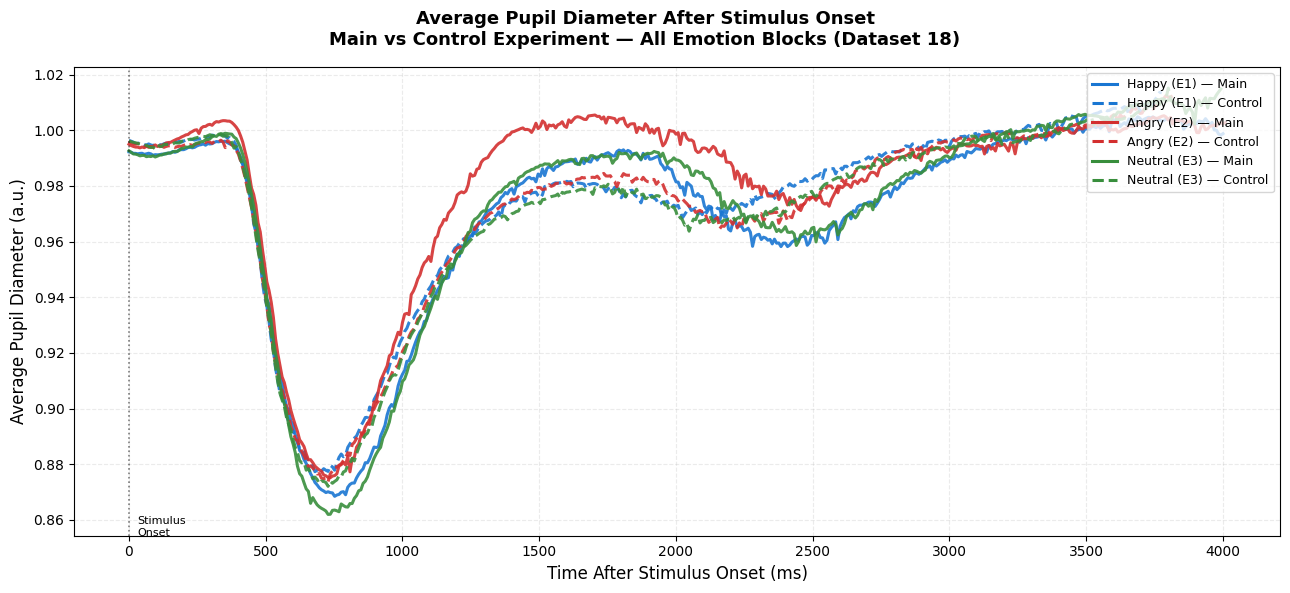

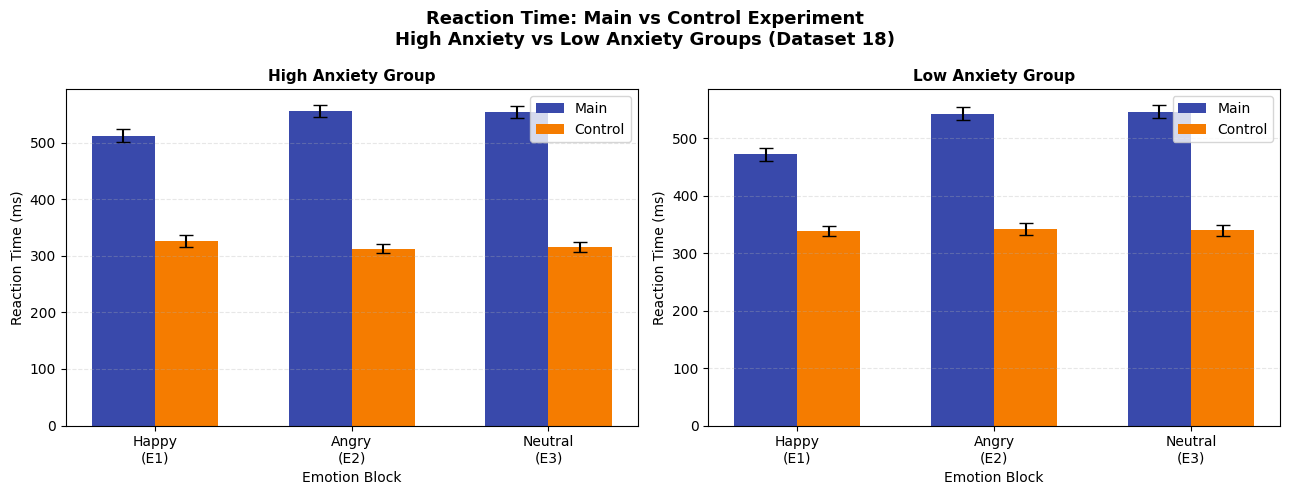

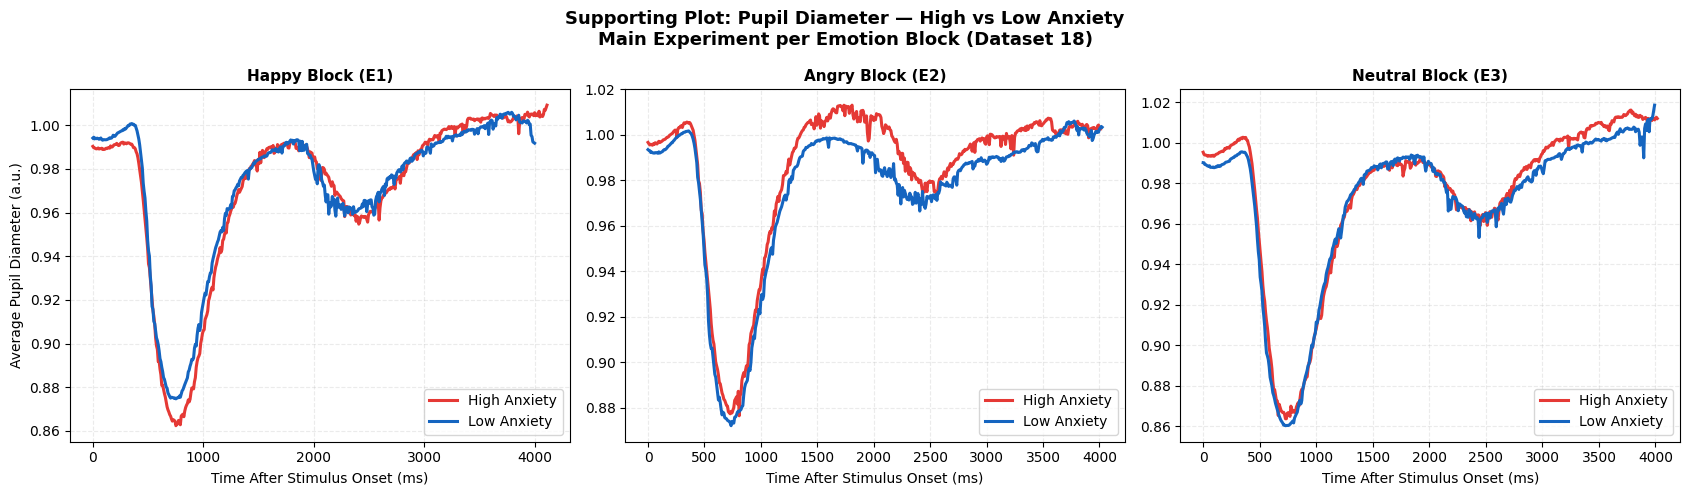

In [19]:
import subprocess
subprocess.run(['pip','install','openpyxl','-q'],check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import os,warnings
warnings.filterwarnings('ignore')

B  ='/content/18'
blk=['E1','E2','E3']
exp=['main','control']
grp=['high','low']
emo={'E1': 'Happy','E2': 'Angry','E3': 'Neutral'}
PS=4
FC=87
SC=PS+FC
PWM=5000
PWC=PWM//8

dat={}
for b in blk:
    for e in exp:
        for g in grp:
            fn=f"{b}_{e}_{g}_final.csv"
            fp=os.path.join(B,fn)
            try:
                df=pd.read_csv(fp,header=None,skiprows=1)
                dat[(b,e,g)]=df
            except FileNotFoundError:
                print(f"NOT FOUND: {fn}")

ap={}
rtd={}
for k,df in dat.items():
    pr=df.iloc[:,SC:].apply(pd.to_numeric,errors='coerce')
    pr=pr.replace(0,np.nan)
    nc=min(pr.shape[1],PWC)
    pt=pr.iloc[:,:nc]
    vc=pt.notna().sum(axis=0)
    thr=0.3*len(pt)
    vld=vc>thr
    pc=pt.loc[:,vld]
    ap[k]=np.nanmean(pc.values,axis=0)

    rr=pd.to_numeric(df.iloc[:,3],errors='coerce').dropna().values
    rm=rr.mean() if len(rr) else 0
    rtd[k]=rr*1000 if rm < 10 else rr

cp={}
for b in blk:
    for e in exp:
        tr=[ap[(b,e,g)] for g in grp if (b,e,g) in ap]
        if tr:
            ml=min(len(t) for t in tr)
            cp[(b,e)]=np.mean([t[:ml] for t in tr],axis=0)

bc={'E1': '#1976D2','E2': '#D32F2F','E3': '#388E3C'}
es={'main': 'solid','control': 'dashed'}
f,ax=plt.subplots(figsize=(13,6))
f.suptitle(
    'Average Pupil Diameter After Stimulus Onset\n'
    'Main vs Control Experiment — All Emotion Blocks (Dataset 18)',
    fontsize=13,fontweight='bold'
)

for b in blk:
    for e in exp:
        k=(b,e)
        if k not in cp:
            continue
        tr=cp[k]
        t=np.arange(len(tr))*8
        ax.plot(t,tr,
                color=bc[b],
                linestyle=es[e],
                linewidth=2.2,
                alpha=0.9)

ax.axvline(x=0,color='black',linestyle=':',linewidth=1.2,alpha=0.5)
ax.text(30,ax.get_ylim()[0],'Stimulus\nOnset',fontsize=8)

ax.set_xlabel('Time After Stimulus Onset (ms)',fontsize=12)
ax.set_ylabel('Average Pupil Diameter (a.u.)',fontsize=12)
ax.grid(True,alpha=0.25,linestyle='--')

lh=[]
for b in blk:
    for e in exp:
        lh.append(
            Line2D([0],[0],
                   color=bc[b],
                   linestyle=es[e],
                   lw=2.2,
                   label=f"{emo[b]} ({b}) — {e.capitalize()}")
        )

ax.legend(handles=lh,fontsize=9,loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(B,'plot1.png'),dpi=150)
plt.show()
ec={'main': '#3949AB','control': '#F57C00'}
x=np.arange(len(blk))
w=0.32
xl=[f"{emo[b]}\n({b})" for b in blk]

f,axs=plt.subplots(1,2,figsize=(13,5))
f.suptitle(
    'Reaction Time: Main vs Control Experiment\n'
    'High Anxiety vs Low Anxiety Groups (Dataset 18)',
    fontsize=13,fontweight='bold'
)

for ax,gp in zip(axs,['high','low']):
    for i,e in enumerate(exp):
        m,se=[],[]
        for b in blk:
            r=rtd.get((b,e,gp),np.array([np.nan]))
            m.append(np.nanmean(r))
            se.append(stats.sem(r,nan_policy='omit') if len(r)>1 else 0)
        ax.bar(x+(i-0.5)*w,m,w,
               yerr=se,capsize=5,
               color=ec[e],
               label=e.capitalize())
    ax.set_title(f"{gp.capitalize()} Anxiety Group",fontsize=11,fontweight='bold')
    ax.set_xlabel('Emotion Block')
    ax.set_ylabel('Reaction Time (ms)')
    ax.set_xticks(x)
    ax.set_xticklabels(xl)
    ax.legend()
    ax.grid(axis='y',linestyle='--',alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(B,'plot2.png'),dpi=150)
plt.show()

gc={'high': '#E53935','low': '#1565C0'}

f,axs=plt.subplots(1,3,figsize=(17,5))
f.suptitle(
    'Supporting Plot: Pupil Diameter — High vs Low Anxiety\n'
    'Main Experiment per Emotion Block (Dataset 18)',
    fontsize=13,fontweight='bold'
)

for ax,b in zip(axs,blk):
    for g in grp:
        k=(b,'main',g)
        if k not in ap:
            continue
        tr=ap[k]
        t=np.arange(len(tr))*8
        ax.plot(t,tr,
                color=gc[g],
                linewidth=2.2,
                label=f"{g.capitalize()} Anxiety")

    ax.set_title(f"{emo[b]} Block ({b})",fontsize=11,fontweight='bold')
    ax.set_xlabel('Time After Stimulus Onset (ms)')
    ax.grid(True,linestyle='--',alpha=0.25)
    ax.legend()
axs[0].set_ylabel('Average Pupil Diameter (a.u.)')
plt.tight_layout()
plt.savefig(os.path.join(B,'plot3.png'),dpi=150)
plt.show()

